###Initial imports and data processing


In [3]:
import cv2
import numpy as np
import torch
import zipfile, os
import shutil
import matplotlib.pyplot as plt
from ultralytics import YOLO


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os
print(os.listdir('/content/drive/MyDrive'))

Mounted at /content/drive
['How to get started with Drive.pdf', 'Weather for geography.gslides', 'Schedule.gsheet', 'Annual budget.gsheet', 'Untitled spreadsheet.gsheet', 'J.D', 'T.D', 'Pungken scoop', 'Hi.gdoc', 'B͓̽r͓̽e͓̽n͓̽d͓̽e͓̽n͓̽o͓̽o͓̽s͓̽.gdoc', 'Sophy Sophie .gdoc', 'Colonial Newspaper Template.doc.gdoc', 'Untitled form (2).gform', 'Untitled form (1).gform', 'Untitled form.gform', 'Copy of Team XX Final Design Presentation - DUPLICATE A COPY.gslides', 'Josh Dinn - Resume.pdf', '02 - Workshop and Practice Files', 'Bali photos', 'Joshua_Dinn_Resume (Dad edit).pdf', 'Joshua_Dinn_Resume (Dad edit).gdoc', 'IMG_6120 (1).HEIC', 'IMG_6112 (1).HEIC', 'IMG_0789 (1).HEIC', 'IMG_6121 (1).HEIC', 'IMG_6100 (1).HEIC', 'IMG_0790 (1).HEIC', 'IMG_6128 (1).HEIC', 'IMG_6129 (1).HEIC', 'IMG_6123 (1).HEIC', 'IMG_6118 (1).HEIC', 'IMG_6137 (1).HEIC', 'IMG_6114 (1).HEIC', 'IMG_6130 (1).HEIC', 'IMG_6158 (1).HEIC', 'IMG_6128.HEIC', 'IMG_6129.HEIC', 'IMG_6114.HEIC', 'IMG_6120.HEIC', 'IMG_6118.HEIC', 'IMG_6

In [5]:
src = '/content/drive/MyDrive/StrawDI_Db1.zip'
dst = '/content/StrawDI_Db1.zip'

shutil.copy(src, dst)
print("Copied to local Colab disk:", dst)

Copied to local Colab disk: /content/StrawDI_Db1.zip


In [6]:
extract_dir = './strawdi_data'

with zipfile.ZipFile(dst, 'r') as zf:
    zf.extractall(extract_dir)

print("Extracted to:", os.path.abspath(extract_dir))

Extracted to: /content/strawdi_data


In [7]:
splits = {
    'train': os.path.join(extract_dir, 'StrawDI_Db1/train', 'img'),
    'val':   os.path.join(extract_dir, 'StrawDI_Db1/val', 'img'),
    'test':  os.path.join(extract_dir, 'StrawDI_Db1/test', 'img'),
}

for name, path in splits.items():
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg', '.png'))])
        print(f"{name}: {count} images")
    else:
        print(f"{name}: path not found, adjust based on print_tree output")

train: 2800 images
val: 100 images
test: 200 images


In [8]:
img_path = os.path.join(extract_dir, 'StrawDI_Db1/train', 'img', '1.png')   # fill in a real filename from print_tree
label_path = os.path.join(extract_dir, 'StrawDI_Db1/train', 'label', '1.png')

img = cv2.imread(img_path)
mask = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)

print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
print("Unique mask values (0 = background, rest = individual strawberries):", np.unique(mask))

Image shape: (756, 1008, 3)
Mask shape: (756, 1008)
Unique mask values (0 = background, rest = individual strawberries): [0 1 2 3 4]


### Checking data quality and saving labels

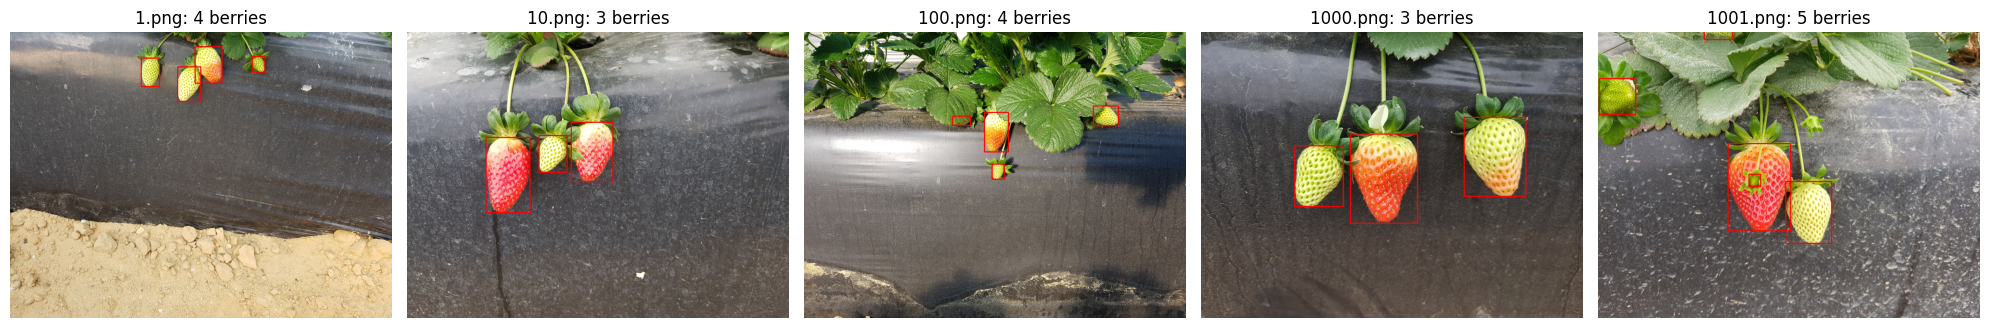

In [9]:
img_dir = os.path.join(extract_dir, 'StrawDI_Db1/train', 'img')
label_dir = os.path.join(extract_dir, 'StrawDI_Db1/train', 'label')

sample_files = sorted(os.listdir(img_dir))[:5]

def mask_to_boxes(mask):
    boxes = []
    for instance_id in np.unique(mask):
        if instance_id == 0:
            continue
        ys, xs = np.where(mask == instance_id)
        boxes.append((xs.min(), ys.min(), xs.max(), ys.max()))
    return boxes

fig, axes = plt.subplots(1, len(sample_files), figsize=(20, 4))

for ax, fname in zip(axes, sample_files):
    img = cv2.imread(os.path.join(img_dir, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(label_dir, fname), cv2.IMREAD_GRAYSCALE)

    for (xmin, ymin, xmax, ymax) in mask_to_boxes(mask):
        cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)

    ax.imshow(img)
    ax.set_title(f"{fname}: {len(np.unique(mask)) - 1} berries")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def mask_to_yolo_seg_labels(mask_path, class_id=0, epsilon_frac=0.002, min_area=10):
    """Convert an instance mask into YOLO-seg polygon labels instead of boxes,
    so we keep berry shape/overlap info instead of collapsing it to a rectangle."""
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    h, w = mask.shape
    lines = []

    for instance_id in np.unique(mask):
        if instance_id == 0:
            continue

        instance_mask = (mask == instance_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(instance_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue

        contour = max(contours, key=cv2.contourArea)  # largest blob if split into pieces
        if cv2.contourArea(contour) < min_area:
            continue

        epsilon = epsilon_frac * cv2.arcLength(contour, True)
        contour = cv2.approxPolyDP(contour, epsilon, True)  # simplify point count

        points = contour.reshape(-1, 2)
        if len(points) < 3:
            continue

        norm_points = []
        for x, y in points:
            norm_points.append(f"{x / w:.6f}")
            norm_points.append(f"{y / h:.6f}")

        lines.append(f"{class_id} " + " ".join(norm_points))

    return lines


def convert_split(img_dir, label_dir, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    filenames = os.listdir(label_dir)

    for fname in filenames:
        mask_path = os.path.join(label_dir, fname)
        lines = mask_to_yolo_seg_labels(mask_path)   # <-- only line that changed here

        out_name = os.path.splitext(fname)[0] + '.txt'
        with open(os.path.join(out_dir, out_name), 'w') as f:
            f.write('\n'.join(lines))

    print(f"Converted {len(filenames)} label files -> {out_dir}")

convert_split(
    img_dir=os.path.join(extract_dir, 'StrawDI_Db1/train', 'img'),
    label_dir=os.path.join(extract_dir, 'StrawDI_Db1/train', 'label'),
    out_dir=os.path.join(extract_dir, 'StrawDI_Db1/train', 'labels_yolo')
)
convert_split(
    img_dir=os.path.join(extract_dir, 'StrawDI_Db1/test', 'img'),
    label_dir=os.path.join(extract_dir, 'StrawDI_Db1/test', 'label'),
    out_dir=os.path.join(extract_dir, 'StrawDI_Db1/test', 'labels_yolo')
)
convert_split(
    img_dir=os.path.join(extract_dir, 'StrawDI_Db1/val', 'img'),
    label_dir=os.path.join(extract_dir, 'StrawDI_Db1/val', 'label'),
    out_dir=os.path.join(extract_dir, 'StrawDI_Db1/val', 'labels_yolo')
)

Converted 2800 label files -> ./strawdi_data/StrawDI_Db1/train/labels_yolo
Converted 200 label files -> ./strawdi_data/StrawDI_Db1/test/labels_yolo
Converted 100 label files -> ./strawdi_data/StrawDI_Db1/val/labels_yolo


## Just a sanity check


In [ ]:
check_img_dir = os.path.join(extract_dir, 'StrawDI_Db1/train', 'img')
check_lbl_dir = os.path.join(extract_dir, 'StrawDI_Db1/train', 'labels_yolo')
sample_files = sorted(os.listdir(check_img_dir))[:5]

fig, axes = plt.subplots(1, len(sample_files), figsize=(20, 4))
for ax, fname in zip(axes, sample_files):
    img = cv2.imread(os.path.join(check_img_dir, fname))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    label_path = os.path.join(check_lbl_dir, os.path.splitext(fname)[0] + '.txt')
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.split()
                if len(parts) < 7:
                    continue
                coords = list(map(float, parts[1:]))
                pts = np.array(coords, dtype=np.float32).reshape(-1, 2)
                pts[:, 0] *= w
                pts[:, 1] *= h
                cv2.polylines(img, [pts.astype(np.int32)], isClosed=True, color=(255, 0, 0), thickness=2)

    ax.imshow(img)
    ax.set_title(fname)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Compute a quick fingerprint for each image to check for similarity

In [ ]:
def dhash(image_path, hash_size=8):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (hash_size + 1, hash_size))
    diff = img[:, 1:] > img[:, :-1]
    return tuple(diff.flatten())

hashes = {}
for split in ['train', 'val', 'test']:
    img_dir = os.path.join(extract_dir, 'StrawDI_Db1', split, 'img')
    for fname in os.listdir(img_dir):
        h = dhash(os.path.join(img_dir, fname))
        hashes.setdefault(h, []).append((split, fname))

leaks = {h: locs for h, locs in hashes.items() if len(set(s for s, _ in locs)) > 1}
print(f"Found {len(leaks)} near-duplicate images appearing across more than one split.")
for h, locs in list(leaks.items())[:5]:
    print(locs)

# Training the model

In [ ]:
MODEL_SIZE = "n"  # nano to start; bump to "s" or "m" if train+val loss both plateau high (underfitting)
model = YOLO(f"yolo26{MODEL_SIZE}-seg.pt")

# model.tune(
#     data="strawberry_data.yaml",
#     epochs=30,
#     iterations=100,
#     optimizer="AdamW",
#     plots=False,
#     save=False,
# )

In [12]:
base = './strawdi_data/StrawDI_Db1'

for split in ['train', 'val', 'test']:
    img_src = os.path.join(base, split, 'img')
    img_dst = os.path.join(base, split, 'images')
    lbl_src = os.path.join(base, split, 'labels_yolo')
    lbl_dst = os.path.join(base, split, 'labels')

    if os.path.exists(img_src) and not os.path.exists(img_dst):
        shutil.move(img_src, img_dst)
    if os.path.exists(lbl_src) and not os.path.exists(lbl_dst):
        shutil.move(lbl_src, lbl_dst)

    print(f"{split}: {len(os.listdir(img_dst))} images, {len(os.listdir(lbl_dst))} labels")

train: 2800 images, 2800 labels
val: 100 images, 100 labels
test: 200 images, 200 labels


In [ ]:
PROJECT = "strawberry_runs"
RUN_NAME = "v2_strawdi_seg"

# For when we get model.tune working

# results = model.train(
#     data="strawberry_data.yaml",
#     cfg="runs/segment/tune/best_hyperparameters.yaml",  # loads lr0, weight_decay, hsv_*, degrees, mosaic, mixup, copy_paste, etc. from the tuning run
#     epochs=100,
#     imgsz=640,
#     batch=16,
#     patience=20,
#     dropout=0.1,           # not covered by tune() — keep this explicit
#     cos_lr=True,
#     multi_scale=True,
#     close_mosaic=10,
#     project=PROJECT,
#     name=RUN_NAME,
# )

results = model.train(
    data="strawberry_data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    weight_decay=0.0005,
    dropout=0.1,
    label_smoothing=0.0,
    cos_lr=True,
    warmup_epochs=3,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.3,
    close_mosaic=10,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=10, translate=0.1, scale=0.5, shear=2.0, perspective=0.0005,
    project=PROJECT,
    name=RUN_NAME,
    multi_scale=True
)

Ultralytics 8.4.125 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=strawberry_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1_strawdi, nbs=64, nms=False, opset=None

In [ ]:
metrics = model.val(augment=True)
print("Box mAP@0.5:", metrics.box.map50)
print("Box mAP@0.5:0.95:", metrics.box.map)

if hasattr(metrics, "seg"):
    print("Mask mAP@0.5:", metrics.seg.map50)
    print("Mask mAP@0.5:0.95:", metrics.seg.map)

print("\nPrecision (per class):", metrics.box.p)
print("Recall (per class):", metrics.box.r)
print("\nConfusion matrix + PR curves saved to:", metrics.save_dir)

Ultralytics 8.4.125 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3445.4±181.9 MB/s, size: 1454.0 KB)
val: Scanning /content/strawdi_data/StrawDI_Db1/val/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 23.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.1it/s 6.1s
                   all        100        572      0.981      0.926      0.967      0.837
Speed: 7.0ms preprocess, 9.9ms inference, 0.0ms loss, 6.1ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5: 0.9668940068649874
mAP@0.5:0.95: 0.836782183668473


In [ ]:
best_weights = os.path.join(PROJECT, RUN_NAME, "weights", "best.pt")

os.makedirs('/content/drive/MyDrive/HarvestAI/models', exist_ok=True)
shutil.copy(
    best_weights,
    '/content/drive/MyDrive/HarvestAI/models/strawberry_v2.pt'
)
print("Saved:", best_weights)

'/content/drive/MyDrive/HarvestAI/models/strawberry_v1.pt'